# Chapter 09: Epipolar Geometry and the Fundamental Matrix

Source orientation: printed pages 239-261; PDF pages 257-279.

This notebook is an original visualization-first treatment of Chapter 09. The source span was used only to ground the section map and vocabulary: epipolar geometry, the fundamental matrix F, epipoles, special motions, geometric representation, projective camera retrieval, and the essential matrix. No textbook prose, figures, screenshots, page crops, or long exercise text are reproduced.


## Chapter Goal

Learn to read the fundamental matrix as a geometric machine: a rank-two projective map that sends a point in one image to the epipolar line in the other, with epipoles as nullspaces and calibration adding the stricter essential-matrix singular-value pattern.

The chapter's route is concrete:

1. Build a calibrated two-camera rig and a small 3D scene.
2. Visualize the epipolar pencil as planes through the baseline.
3. Verify `l_prime = F x` and `x_prime.T F x = 0` on image overlays.
4. Compare general motion with special translation where epipoles move to infinity.
5. Upgrade from `F` to `E = K_prime.T F K` and check the essential-matrix signature.


## Translation Guide

- **Epipolar plane:** a plane through both camera centers and one scene point. Its intersections with the two image planes are corresponding epipolar lines.
- **Fundamental matrix:** a homogeneous `3 x 3` rank-two matrix. It represents a point-to-line correlation, so scale does not matter but rank, nullspaces, and incidence do.
- **Epipoles:** the images of the opposite camera centers. Algebraically, `F e = 0` and `F.T e_prime = 0`.
- **Special motion:** particular rotations/translations make the epipoles finite, far away, or exactly at infinity; the matrix still has rank two when the camera centers differ.
- **Camera retrieval:** `F` determines a canonical camera pair only up to a projective transformation of 3-space, so this notebook checks the canonical invariants rather than claiming a metric reconstruction from `F` alone.
- **Essential matrix:** after calibration, the same epipolar constraint uses normalized image coordinates. A valid `E` has two equal nonzero singular values and one zero singular value.


## Visual Storyboard And Library Routing

| Visual | Concept | Library route | What to inspect | Check |
| --- | --- | --- | --- | --- |
| `figures/epipolar-fan-geometry.png` | Epipolar planes, baseline, image planes, epipoles | NumPy camera geometry, Matplotlib 3D, Plotly HTML companion when available | Each scene point selects one plane through the baseline; all image-plane intersections pass through the epipole | `F` has rank two; epipoles are right/left nullspaces |
| `figures/point-to-epiline-map.png` | Point-to-line map `x -> l_prime = F x` | OpenCV `computeCorrespondEpilines`, Matplotlib overlays | Moving the point in view 1 moves a line in view 2; true matches lie on those lines | `x_prime.T F x` residual and OpenCV line agreement |
| `figures/special-motion-epipoles.png` | General versus special pure translation | NumPy plus Matplotlib line pencils | Finite epipole gives a visible pencil intersection; lateral translation sends the epipole to infinity and lines become parallel | both `F` matrices have rank two |
| `figures/essential-singular-values.png` and `checks/epipolar-invariants.json` | Calibration upgrade from `F` to `E` | OpenCV `findEssentialMat`, NumPy SVD, Matplotlib bars | Calibration imposes equal nonzero singular values; the projected diagnostic repairs small numerical scale differences | singular-value pattern and epipolar invariants |


In [1]:
from pathlib import Path
import json
import math
import sys

import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import numpy as np

try:
    import plotly.graph_objects as go
except Exception:
    go = None

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the MVG book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, display_artifact, save_json, save_matplotlib, save_plotly_html
from utils.cameras import camera_matrix, look_at_rotation, make_calibration, project_points, skew
from utils.epipolar import enforce_rank2, sampson_errors
from utils.projective import dehomogenize, homogenize

TOPIC = "chapter-09"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / TOPIC
FIG_DIR = ARTIFACT_ROOT / "figures"
CHECK_DIR = ARTIFACT_ROOT / "checks"
HTML_DIR = ARTIFACT_ROOT / "interactive"
for path in [FIG_DIR, CHECK_DIR, HTML_DIR]:
    path.mkdir(parents=True, exist_ok=True)

artifact_paths = []
check_paths = []
np.set_printoptions(precision=5, suppress=True)


In [2]:
def normalize_h(x, prefer_last=True):
    x = np.asarray(x, dtype=float).reshape(-1)
    if prefer_last and abs(x[-1]) > 1e-12:
        return x / x[-1]
    n = np.linalg.norm(x)
    return x / n if n > 1e-12 else x


def null_vector(A):
    _, _, vt = np.linalg.svd(np.asarray(A, dtype=float))
    return normalize_h(vt[-1], prefer_last=abs(vt[-1, -1]) > 1e-10)


def fundamental_from_KRt(K1, K2, R, t):
    E = skew(t) @ R
    F = np.linalg.inv(K2).T @ E @ np.linalg.inv(K1)
    return enforce_rank2(F), E


def make_rig(kind="general"):
    K = make_calibration(760.0, 740.0, 320.0, 240.0)
    R1 = np.eye(3)
    C1 = np.zeros(3)
    if kind == "general":
        C2 = np.array([1.15, 0.18, 0.32])
        R2 = look_at_rotation(C2, target=np.array([0.0, 0.0, 4.2]))
    elif kind == "lateral":
        C2 = np.array([1.05, 0.0, 0.0])
        R2 = np.eye(3)
    elif kind == "forward":
        C2 = np.array([0.0, 0.0, -0.85])
        R2 = np.eye(3)
    else:
        raise ValueError(kind)
    t2 = -R2 @ C2
    P1 = camera_matrix(K, R1, C1)
    P2 = camera_matrix(K, R2, C2)
    F, E = fundamental_from_KRt(K, K, R2, t2)
    return {"K": K, "R1": R1, "R2": R2, "C1": C1, "C2": C2, "t2": t2, "P1": P1, "P2": P2, "F": F, "E": E}


def scene_points():
    return np.array([
        [-0.75, -0.35, 3.2],
        [-0.25, 0.42, 3.65],
        [0.38, -0.2, 4.05],
        [0.78, 0.36, 4.55],
        [0.05, 0.05, 5.05],
        [-0.55, 0.2, 4.7],
    ], dtype=float)


def camera_plane_corners(C, R, half_width=0.65, half_height=0.45, distance=1.0):
    local = np.array([
        [-half_width, -half_height, distance],
        [half_width, -half_height, distance],
        [half_width, half_height, distance],
        [-half_width, half_height, distance],
    ])
    return C + (R.T @ local.T).T


def image_plane_point(C, R, xy, scale=1.0):
    xy = np.asarray(xy, dtype=float)
    local = np.array([xy[0] * scale, xy[1] * scale, scale])
    return C + R.T @ local


def line_segment(line, width=640, height=480, pad=30):
    a, b, c = np.asarray(line, dtype=float)
    candidates = []
    for x in [-pad, width + pad]:
        if abs(b) > 1e-12:
            y = -(a * x + c) / b
            if -pad <= y <= height + pad:
                candidates.append((x, y))
    for y in [-pad, height + pad]:
        if abs(a) > 1e-12:
            x = -(b * y + c) / a
            if -pad <= x <= width + pad:
                candidates.append((x, y))
    if len(candidates) < 2:
        return None
    return np.array(candidates[:2], dtype=float)


def epipole_from_F(F, side):
    return null_vector(F if side == "right" else F.T)


def epipolar_residuals(F, x1, x2):
    h1 = homogenize(x1)
    h2 = homogenize(x2)
    return np.sum(h2 * (F @ h1.T).T, axis=1)

rig = make_rig("general")
X = scene_points()
x1 = project_points(rig["P1"], X)
x2 = project_points(rig["P2"], X)
F = rig["F"]
E = rig["E"]
e1 = epipole_from_F(F, "right")
e2 = epipole_from_F(F, "left")
e1_from_camera = normalize_h(rig["P1"] @ np.r_[rig["C2"], 1.0])
e2_from_camera = normalize_h(rig["P2"] @ np.r_[rig["C1"], 1.0])
residuals = epipolar_residuals(F, x1, x2)
rank_F = int(np.linalg.matrix_rank(F, tol=1e-9))
print("F rank:", rank_F)
print("right epipole e:", e1)
print("left epipole e_prime:", e2)
print("max |x_prime.T F x|:", float(np.max(np.abs(residuals))))


F rank: 2
right epipole e: [3051.25  656.25    1.  ]
left epipole e_prime: [32750.974  -4494.1224     1.    ]
max |x_prime.T F x|: 1.4077627952246985e-13


## 1. Two-Camera Epipolar Fan In 3D

The epipolar geometry is easiest to see before it becomes a matrix. Each 3D point chooses a plane through the baseline. That plane cuts the first and second image planes in a paired pair of epipolar lines. The epipoles are where the baseline itself pierces the image planes, and the matrix check says the same thing in algebraic language: the epipoles are null-vectors of `F`.


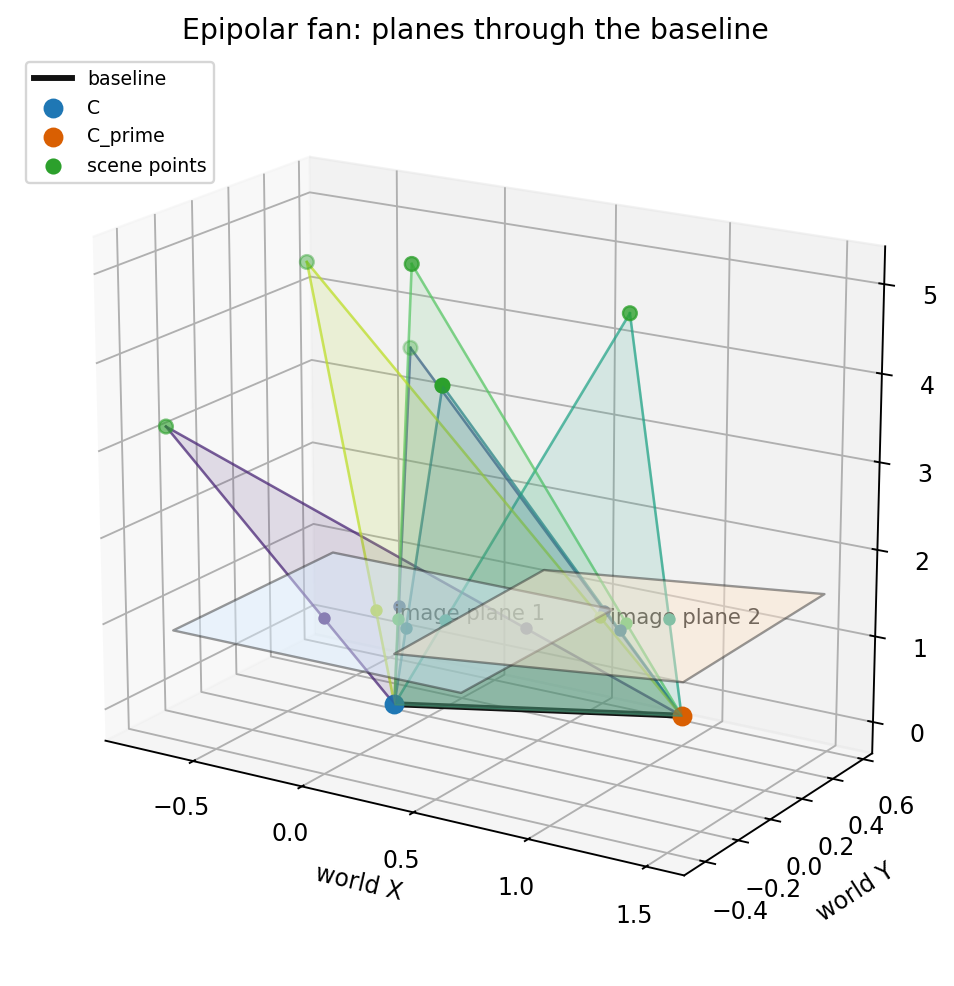

{'rank_F': 2,
 'right_null_residual_norm': 1.895150706212136e-13,
 'left_null_residual_norm': 2.1505243549350696e-13,
 'right_epipole_matches_camera_projection': 4.247077941753914e-10,
 'left_epipole_matches_camera_projection': 2.890538932621871e-08}

In [3]:
fig = plt.figure(figsize=(9.5, 7.0))
ax = fig.add_subplot(111, projection="3d")
C1, C2 = rig["C1"], rig["C2"]
plane1 = camera_plane_corners(C1, rig["R1"])
plane2 = camera_plane_corners(C2, rig["R2"])

for plane, color, label in [(plane1, "#d8ecff", "image plane 1"), (plane2, "#ffe5cc", "image plane 2")]:
    ax.add_collection3d(Poly3DCollection([plane], alpha=0.45, facecolor=color, edgecolor="#222222", linewidth=1.0))
    center = plane.mean(axis=0)
    ax.text(*center, label, fontsize=9)

ax.plot(*np.vstack([C1, C2]).T, color="#111111", lw=2.5, label="baseline")
ax.scatter(*C1, s=55, color="#1f77b4", label="C")
ax.scatter(*C2, s=55, color="#d95f02", label="C_prime")
ax.scatter(X[:, 0], X[:, 1], X[:, 2], s=34, color="#2ca02c", label="scene points")

colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(X)))
for Xi, x1i, x2i, color in zip(X, x1, x2, colors):
    ax.plot(*np.vstack([C1, Xi]).T, color=color, lw=1.1, alpha=0.7)
    ax.plot(*np.vstack([C2, Xi]).T, color=color, lw=1.1, alpha=0.7)
    fan = np.vstack([C1, C2, Xi])
    ax.add_collection3d(Poly3DCollection([fan], alpha=0.14, facecolor=color, edgecolor=color, linewidth=0.7))
    p1 = image_plane_point(C1, rig["R1"], (x1i - np.array([320, 240])) / np.array([760, 740]))
    p2 = image_plane_point(C2, rig["R2"], (x2i - np.array([320, 240])) / np.array([760, 740]))
    ax.scatter(*p1, s=18, color=color)
    ax.scatter(*p2, s=18, color=color)

ax.set_title("Epipolar fan: planes through the baseline")
ax.set_xlabel("world X")
ax.set_ylabel("world Y")
ax.set_zlabel("world Z")
ax.view_init(elev=18, azim=-58)
ax.set_box_aspect([1.6, 0.9, 1.25])
ax.legend(loc="upper left", fontsize=8)
fan_path = save_matplotlib(fig, TOPIC, "figures", "epipolar-fan-geometry.png", dpi=170)
plt.close(fig)
artifact_paths.append(fan_path)
display_artifact(fan_path, width=860)

fan_html_path = None
if go is not None:
    traces = [
        go.Scatter3d(x=[C1[0], C2[0]], y=[C1[1], C2[1]], z=[C1[2], C2[2]], mode="lines+markers", name="baseline", line=dict(color="black", width=6)),
        go.Scatter3d(x=X[:,0], y=X[:,1], z=X[:,2], mode="markers", name="scene points", marker=dict(size=4, color="green")),
    ]
    for corners, name, color in [(plane1, "image plane 1", "rgba(90,160,230,0.35)"), (plane2, "image plane 2", "rgba(240,150,70,0.35)")]:
        closed = np.vstack([corners, corners[0]])
        traces.append(go.Scatter3d(x=closed[:,0], y=closed[:,1], z=closed[:,2], mode="lines", name=name, line=dict(width=4)))
        traces.append(go.Mesh3d(x=corners[:,0], y=corners[:,1], z=corners[:,2], i=[0,0], j=[1,2], k=[2,3], opacity=0.28, color=color, name=name + " surface"))
    for idx, Xi in enumerate(X):
        traces.append(go.Scatter3d(x=[C1[0], Xi[0], C2[0]], y=[C1[1], Xi[1], C2[1]], z=[C1[2], Xi[2], C2[2]], mode="lines", name=f"epipolar plane {idx+1}", line=dict(width=2)))
    pfig = go.Figure(traces)
    pfig.update_layout(title="Inspectable epipolar fan", scene=dict(aspectmode="data"), margin=dict(l=0, r=0, t=40, b=0))
    fan_html_path = save_plotly_html(pfig, TOPIC, "interactive", "epipolar-fan-geometry.html")
    artifact_paths.append(fan_html_path)

fan_checks = {
    "rank_F": rank_F,
    "right_null_residual_norm": float(np.linalg.norm(F @ e1)),
    "left_null_residual_norm": float(np.linalg.norm(F.T @ e2)),
    "right_epipole_matches_camera_projection": float(np.linalg.norm(normalize_h(e1) - normalize_h(e1_from_camera))),
    "left_epipole_matches_camera_projection": float(np.linalg.norm(normalize_h(e2) - normalize_h(e2_from_camera))),
}
fan_checks


## 2. Moving Point To Epiline Overlay

The symbolic rule `l_prime = F x` becomes a practical stereo-search reduction: a possible match for `x` in the first image must lie on one line in the second image. This cell asks OpenCV for the same epilines and overlays them on a synthetic image plane. The true projected points land on their corresponding lines, so the residuals should be near machine precision.


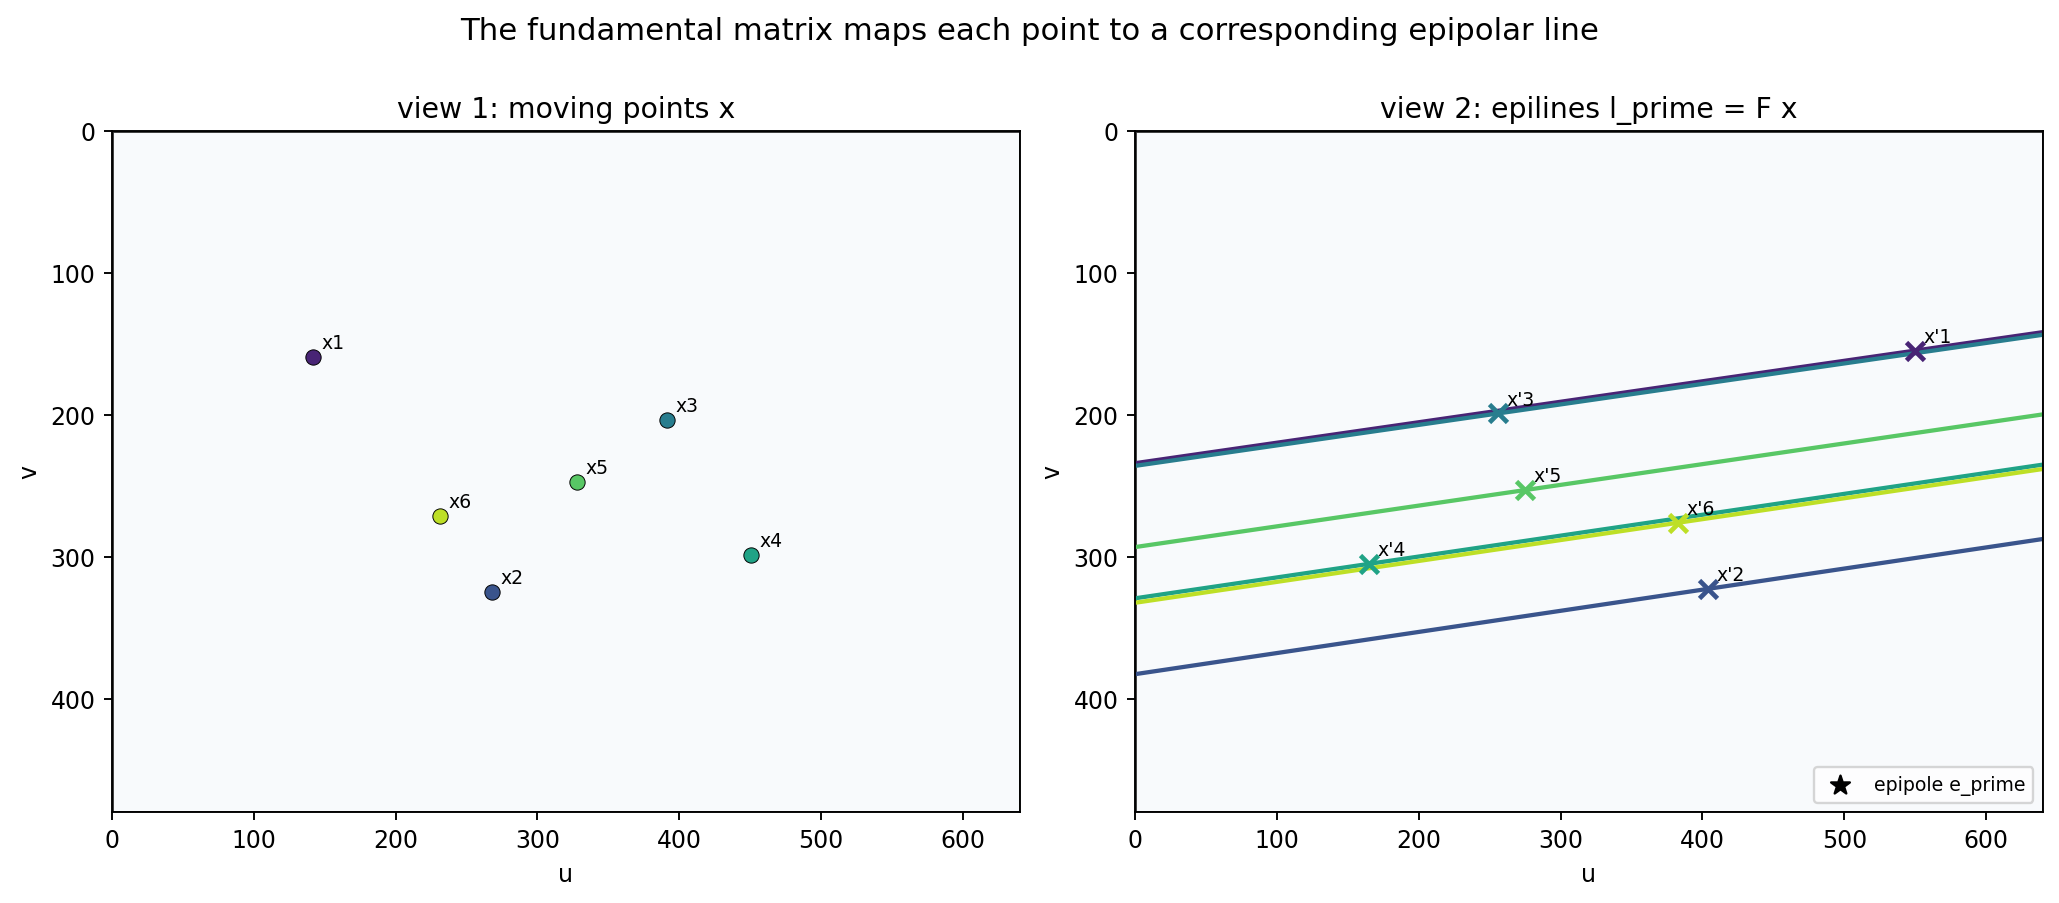

{'max_abs_epipolar_residual': 1.4077627952246985e-13,
 'max_sampson_error': 1.4647894866674357e-22,
 'max_cv2_line_scale_error': 1.1368690548423162e-13}

In [4]:
cv_lines = cv2.computeCorrespondEpilines(x1.reshape(-1, 1, 2).astype(np.float64), 1, F.astype(np.float64)).reshape(-1, 3)
manual_lines = (F @ homogenize(x1).T).T
line_scale_errors = []
for a, b in zip(cv_lines, manual_lines):
    an = a / np.linalg.norm(a[:2])
    bn = b / np.linalg.norm(b[:2])
    line_scale_errors.append(min(np.linalg.norm(an - bn), np.linalg.norm(an + bn)))
line_scale_errors = np.array(line_scale_errors)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), constrained_layout=True)
for ax, title in zip(axes, ["view 1: moving points x", "view 2: epilines l_prime = F x"]):
    ax.add_patch(Rectangle((0, 0), 640, 480, facecolor="#f8fafc", edgecolor="#333333", lw=1.2))
    for gx in range(80, 640, 80):
        ax.axvline(gx, color="#d9e2ec", lw=0.6, zorder=0)
    for gy in range(80, 480, 80):
        ax.axhline(gy, color="#d9e2ec", lw=0.6, zorder=0)
    ax.set_xlim(0, 640)
    ax.set_ylim(480, 0)
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel("u")
    ax.set_ylabel("v")

for idx, (p, q, line, color) in enumerate(zip(x1, x2, cv_lines, colors)):
    axes[0].scatter(*p, s=42, color=color, edgecolor="black", linewidth=0.4, zorder=3)
    axes[0].text(p[0] + 6, p[1] - 6, f"x{idx+1}", fontsize=8)
    seg = line_segment(line)
    if seg is not None:
        axes[1].plot(seg[:, 0], seg[:, 1], color=color, lw=1.8)
    axes[1].scatter(*q, marker="x", s=58, color=color, linewidth=2.0, zorder=4)
    axes[1].text(q[0] + 6, q[1] - 6, f"x'{idx+1}", fontsize=8)

axes[1].scatter(e2[0], e2[1], s=70, color="black", marker="*", label="epipole e_prime")
axes[1].legend(loc="lower right", fontsize=8)
fig.suptitle("The fundamental matrix maps each point to a corresponding epipolar line", fontsize=13)
map_path = save_matplotlib(fig, TOPIC, "figures", "point-to-epiline-map.png", dpi=170)
plt.close(fig)
artifact_paths.append(map_path)
display_artifact(map_path, width=900)

line_map_checks = {
    "max_abs_epipolar_residual": float(np.max(np.abs(residuals))),
    "max_sampson_error": float(np.max(sampson_errors(F, x1, x2))),
    "max_cv2_line_scale_error": float(np.max(line_scale_errors)),
}
line_map_checks


## 3. Special Motion Comparison

A special motion is not a failure by itself. The danger is misreading the epipole. With general motion the epipolar lines form a visible pencil through a finite point. With pure lateral translation, the epipole has homogeneous coordinate `w = 0`, so the line pencil becomes a family of parallel lines. The rank-two condition remains the stable algebraic check.


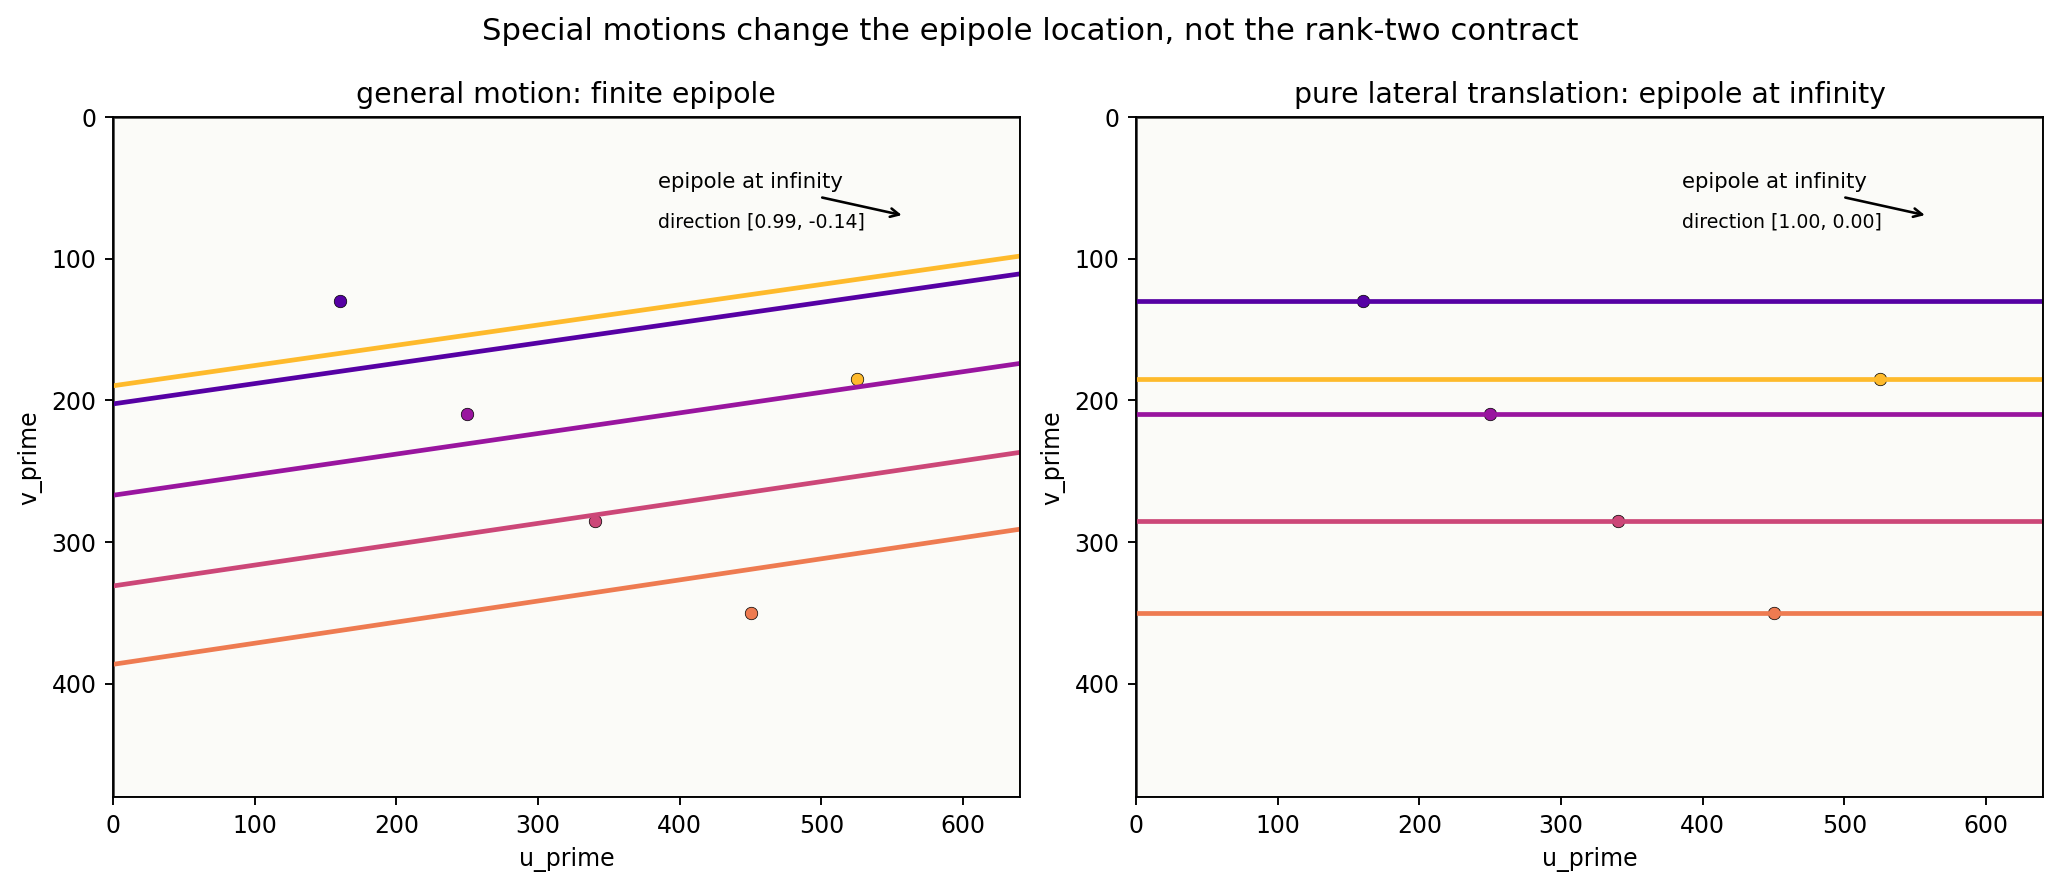

{'general': {'rank': 2,
  'left_epipole': [32750.974003238585, -4494.122400304997, 1.0],
  'left_epipole_w': 1.0},
 'lateral_translation': {'rank': 2,
  'left_epipole': [1.0, 0.0, 0.0],
  'left_epipole_w': 0.0}}

In [5]:
def draw_epiline_panel(ax, rig_case, title):
    Fcase = rig_case["F"]
    pts = np.array([[160, 130], [250, 210], [340, 285], [450, 350], [525, 185]], dtype=float)
    lines = cv2.computeCorrespondEpilines(pts.reshape(-1, 1, 2).astype(np.float64), 1, Fcase.astype(np.float64)).reshape(-1, 3)
    ax.add_patch(Rectangle((0, 0), 640, 480, facecolor="#fbfbf8", edgecolor="#333333", lw=1.1))
    palette = plt.cm.plasma(np.linspace(0.15, 0.85, len(lines)))
    for p, line, color in zip(pts, lines, palette):
        seg = line_segment(line)
        if seg is not None:
            ax.plot(seg[:, 0], seg[:, 1], color=color, lw=2.0)
        ax.scatter(*p, s=28, color=color, edgecolor="black", linewidth=0.3)
    ep = epipole_from_F(Fcase, "left")
    if abs(ep[-1]) > 1e-9 and -250 <= ep[0] <= 900 and -250 <= ep[1] <= 730:
        ax.scatter(ep[0], ep[1], s=95, marker="*", color="black", label="finite epipole")
        ax.legend(loc="lower right", fontsize=8)
    else:
        direction = ep[:2] / (np.linalg.norm(ep[:2]) + 1e-12)
        ax.annotate("epipole at infinity", xy=(560, 70), xytext=(385, 50), arrowprops=dict(arrowstyle="->", lw=1.1), fontsize=9)
        ax.text(385, 78, f"direction [{direction[0]:.2f}, {direction[1]:.2f}]", fontsize=8)
    ax.set_xlim(0, 640)
    ax.set_ylim(480, 0)
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel("u_prime")
    ax.set_ylabel("v_prime")
    return {
        "rank": int(np.linalg.matrix_rank(Fcase, tol=1e-9)),
        "left_epipole": ep.tolist(),
        "left_epipole_w": float(ep[-1]),
    }

general_case = make_rig("general")
lateral_case = make_rig("lateral")
fig, axes = plt.subplots(1, 2, figsize=(12, 5.1), constrained_layout=True)
general_motion_checks = draw_epiline_panel(axes[0], general_case, "general motion: finite epipole")
lateral_motion_checks = draw_epiline_panel(axes[1], lateral_case, "pure lateral translation: epipole at infinity")
fig.suptitle("Special motions change the epipole location, not the rank-two contract", fontsize=13)
special_path = save_matplotlib(fig, TOPIC, "figures", "special-motion-epipoles.png", dpi=170)
plt.close(fig)
artifact_paths.append(special_path)
display_artifact(special_path, width=900)

special_checks = {
    "general": general_motion_checks,
    "lateral_translation": lateral_motion_checks,
}
special_checks


## 4. Essential Upgrade Diagnostic

Calibration changes the coordinate system. With normalized image points, the epipolar matrix becomes `E = K_prime.T F K`; for a true calibrated two-view motion it can also be written as `[t]_x R`. This cell compares the singular values from the true motion, the upgrade from `F`, an OpenCV estimate from image correspondences, and the closest matrix after enforcing the essential singular-value pattern.


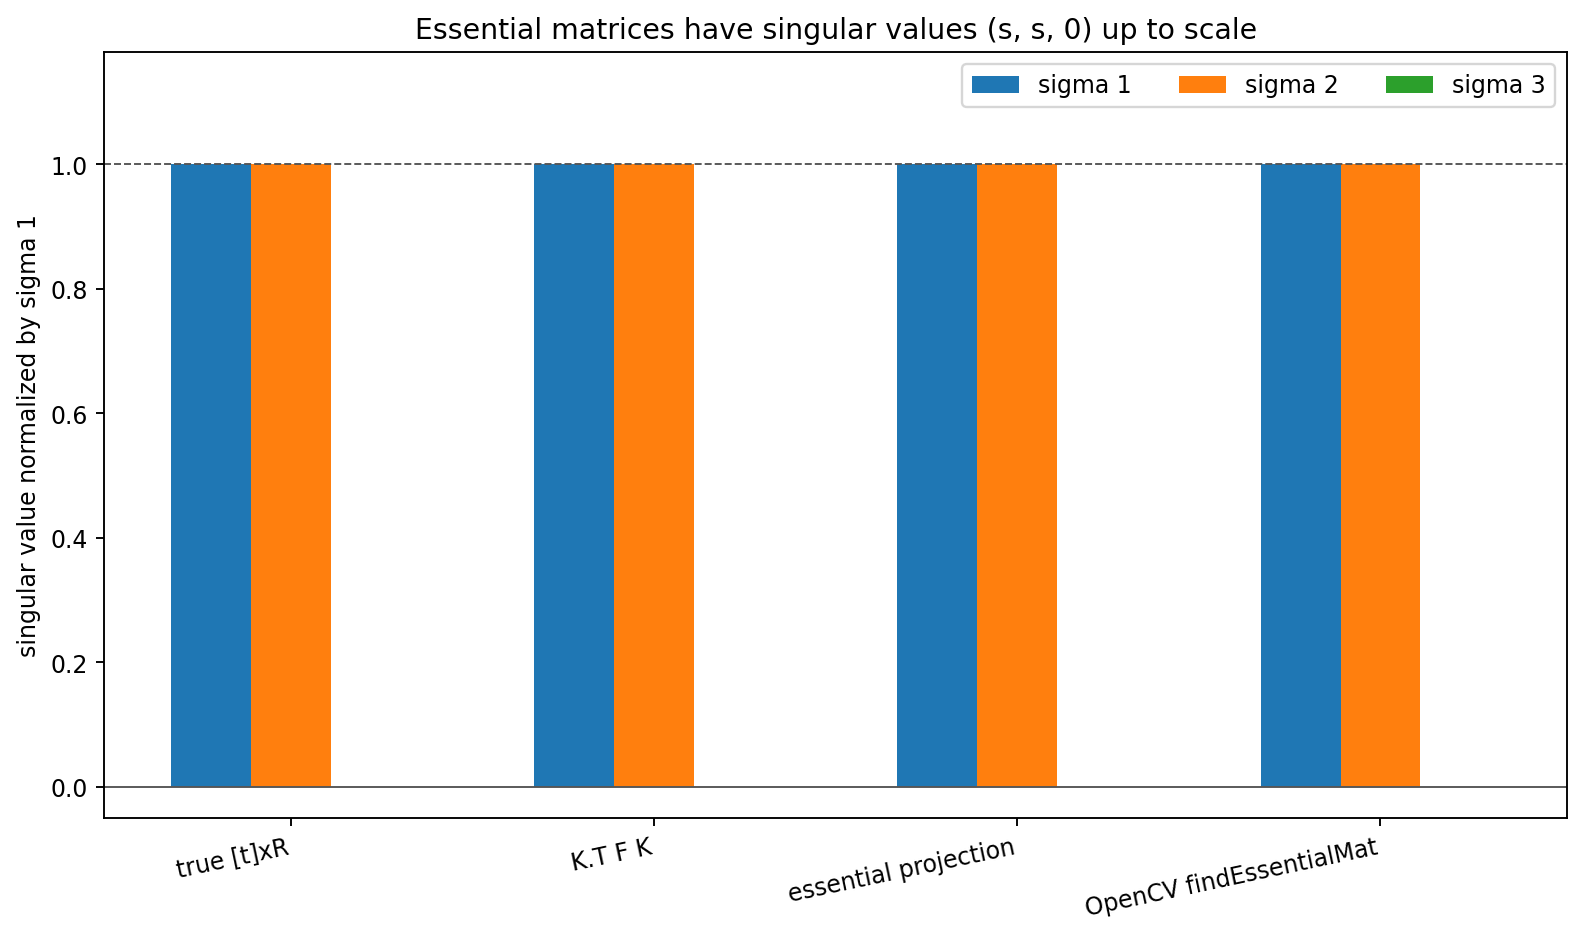

{'true_E_singular_values': [1.2071868123865506,
  1.2071868123865503,
  6.125984616364751e-17],
 'upgraded_E_singular_values': [6.2736925812448,
  6.273692581243692,
  3.318730163243784e-16],
 'projected_E_singular_values': [6.273692581244248,
  6.273692581244247,
  3.588757138148717e-16],
 'opencv_E_singular_values_normalized': [1.0,
  0.9999999999999997,
  4.502261039518236e-16],
 'opencv_inlier_count': 6,
 'essential_equal_nonzero_gap': 1.1102230246251565e-16,
 'essential_zero_tail': 5.720326732102908e-17}

In [6]:
E_from_F = rig["K"].T @ F @ rig["K"]
E_cv, inlier_mask = cv2.findEssentialMat(x1.astype(np.float64), x2.astype(np.float64), rig["K"].astype(np.float64), method=cv2.RANSAC, prob=0.999, threshold=1.0)
if E_cv is not None and E_cv.shape[0] > 3:
    E_cv = E_cv[:3]

def unit_singular_values(M):
    s = np.linalg.svd(M, compute_uv=False)
    return s / (s[0] if s[0] > 1e-12 else 1.0)

U, s_raw, Vt = np.linalg.svd(E_from_F)
s_equal = 0.5 * (s_raw[0] + s_raw[1])
E_projected = U @ np.diag([s_equal, s_equal, 0.0]) @ Vt
sv_sets = {
    "true [t]xR": unit_singular_values(E),
    "K.T F K": unit_singular_values(E_from_F),
    "essential projection": unit_singular_values(E_projected),
}
if E_cv is not None:
    sv_sets["OpenCV findEssentialMat"] = unit_singular_values(E_cv)

fig, ax = plt.subplots(figsize=(9.2, 5.4), constrained_layout=True)
labels = list(sv_sets)
xpos = np.arange(len(labels))
width = 0.22
for j in range(3):
    ax.bar(xpos + (j - 1) * width, [sv_sets[label][j] for label in labels], width=width, label=f"sigma {j+1}")
ax.axhline(1.0, color="#555555", lw=0.8, ls="--")
ax.axhline(0.0, color="#555555", lw=0.8)
ax.set_xticks(xpos)
ax.set_xticklabels(labels, rotation=12, ha="right")
ax.set_ylim(-0.05, 1.18)
ax.set_ylabel("singular value normalized by sigma 1")
ax.set_title("Essential matrices have singular values (s, s, 0) up to scale")
ax.legend(ncols=3, loc="upper right")
essential_path = save_matplotlib(fig, TOPIC, "figures", "essential-singular-values.png", dpi=170)
plt.close(fig)
artifact_paths.append(essential_path)
display_artifact(essential_path, width=860)

essential_checks = {
    "true_E_singular_values": np.linalg.svd(E, compute_uv=False).tolist(),
    "upgraded_E_singular_values": s_raw.tolist(),
    "projected_E_singular_values": np.linalg.svd(E_projected, compute_uv=False).tolist(),
    "opencv_E_singular_values_normalized": sv_sets.get("OpenCV findEssentialMat", np.array([])).tolist(),
    "opencv_inlier_count": int(inlier_mask.sum()) if inlier_mask is not None else 0,
    "essential_equal_nonzero_gap": float(abs(unit_singular_values(E_projected)[0] - unit_singular_values(E_projected)[1])),
    "essential_zero_tail": float(unit_singular_values(E_projected)[2]),
}
essential_checks


## Applied Lab: Diagnose Your Own Stereo Pair

To adapt this notebook to measured correspondences, keep the same artifact contract.

1. Put matched points from the first image in `x1_measured` and the second in `x2_measured`.
2. Estimate or provide `F`, then draw `cv2.computeCorrespondEpilines` overlays on the second image.
3. If calibration `K` is known, compute `E = K.T @ F @ K` and compare its singular values with `(s, s, 0)`.
4. Save both the overlay and a JSON check summary under `artifacts/chapter-09`.

A good stress test is to perturb points with increasing image noise. The raw scalar residual `x_prime.T F x` may stay small under a convenient scale, so also inspect Sampson error and the rank/nullspace diagnostics.


## Pitfalls And Failure Modes

- A `3 x 3` array is not automatically a fundamental matrix. Check rank two, homogeneous scale, epipole nullspaces, and point-line incidence.
- A finite-looking epipole can simply be outside the image. Draw enough of the line pencil to see whether lines are converging inside, outside, or effectively in parallel.
- The relation `x_prime.T F x = 0` is projective. Without calibration, it does not determine a unique Euclidean motion.
- A valid essential matrix has a stricter singular-value pattern than a generic rank-two matrix. Calibration errors or noisy correspondences often show up first as unequal nonzero singular values.
- OpenCV epiline functions use image-index conventions: points from image 1 with `whichImage=1` produce lines in image 2.


In [7]:
invariants = {
    "source_span": {"printed_pages": "239-261", "pdf_pages": "257-279"},
    "libraries": ["numpy", "opencv-contrib-python/cv2", "matplotlib", "plotly optional HTML", "course utils"],
    "fan_checks": fan_checks,
    "line_map_checks": line_map_checks,
    "special_motion_checks": special_checks,
    "essential_checks": essential_checks,
    "artifacts": [str(path.relative_to(BOOK_ROOT)).replace("\\", "/") for path in artifact_paths],
}
checks_path = save_json(invariants, TOPIC, "checks", "epipolar-invariants.json")
check_paths.append(checks_path)
display_artifact(checks_path)
invariants


`artifacts/chapter-09/checks/epipolar-invariants.json`

{'source_span': {'printed_pages': '239-261', 'pdf_pages': '257-279'},
 'libraries': ['numpy',
  'opencv-contrib-python/cv2',
  'matplotlib',
  'plotly optional HTML',
  'course utils'],
 'fan_checks': {'rank_F': 2,
  'right_null_residual_norm': 1.895150706212136e-13,
  'left_null_residual_norm': 2.1505243549350696e-13,
  'right_epipole_matches_camera_projection': 4.247077941753914e-10,
  'left_epipole_matches_camera_projection': 2.890538932621871e-08},
 'line_map_checks': {'max_abs_epipolar_residual': 1.4077627952246985e-13,
  'max_sampson_error': 1.4647894866674357e-22,
  'max_cv2_line_scale_error': 1.1368690548423162e-13},
 'special_motion_checks': {'general': {'rank': 2,
   'left_epipole': [32750.974003238585, -4494.122400304997, 1.0],
   'left_epipole_w': 1.0},
  'lateral_translation': {'rank': 2,
   'left_epipole': [1.0, 0.0, 0.0],
   'left_epipole_w': 0.0}},
 'essential_checks': {'true_E_singular_values': [1.2071868123865506,
   1.2071868123865503,
   6.125984616364751e-17],
  'u

## Final Sanity Checks

The notebook closes by asserting both artifact integrity and the geometry promised in the chapter: `F` has rank two, epipoles are nullspaces, corresponding points satisfy the epipolar constraint, special-motion matrices remain rank two, and the calibrated essential diagnostic has the repeated-nonzero/zero singular-value pattern.


In [8]:
required_artifacts = [
    ARTIFACT_ROOT / "figures" / "epipolar-fan-geometry.png",
    ARTIFACT_ROOT / "figures" / "point-to-epiline-map.png",
    ARTIFACT_ROOT / "figures" / "special-motion-epipoles.png",
    ARTIFACT_ROOT / "figures" / "essential-singular-values.png",
    ARTIFACT_ROOT / "checks" / "epipolar-invariants.json",
]
assert_artifacts(required_artifacts, min_bytes=1500)
assert rank_F == 2
assert fan_checks["right_null_residual_norm"] < 1e-9
assert fan_checks["left_null_residual_norm"] < 1e-9
assert fan_checks["right_epipole_matches_camera_projection"] < 1e-7
assert fan_checks["left_epipole_matches_camera_projection"] < 1e-7
assert line_map_checks["max_abs_epipolar_residual"] < 1e-8
assert line_map_checks["max_sampson_error"] < 1e-14
assert line_map_checks["max_cv2_line_scale_error"] < 1e-9
assert special_checks["general"]["rank"] == 2
assert special_checks["lateral_translation"]["rank"] == 2
assert abs(special_checks["lateral_translation"]["left_epipole_w"]) < 1e-9
projected_sv = unit_singular_values(E_projected)
assert abs(projected_sv[0] - projected_sv[1]) < 1e-12
assert projected_sv[2] < 1e-12
summary = {
    "artifact_count": len(required_artifacts),
    "max_epipolar_residual": line_map_checks["max_abs_epipolar_residual"],
    "F_rank": rank_F,
    "essential_projected_singular_values": projected_sv.tolist(),
}
final_sanity = summary
summary


{'artifact_count': 5,
 'max_epipolar_residual': 1.4077627952246985e-13,
 'F_rank': 2,
 'essential_projected_singular_values': [1.0,
  0.9999999999999999,
  5.720326732102908e-17]}

## Takeaways

- The epipolar pencil is the 3D object behind the matrix: every point selects a plane through the baseline, and every such plane cuts matching epipolar lines in the two images.
- `F` is a point-to-line map, not a point-to-point map. The check is incidence: `x_prime.T F x = 0`.
- The epipoles are not extra decorations on the figure; they are the right and left nullspaces of `F`.
- Special motions move epipoles to finite, distant, or infinite positions, while the fundamental matrix remains rank two for non-coincident camera centers.
- Calibration upgrades the projective relation to an essential matrix with singular values `(s, s, 0)`, preparing the camera-motion extraction discussed at the end of the chapter.
